# 11 — Linear Classifier Model Selection

Training finds model parameters such as `W` and `b`. Model selection chooses hyperparameters such as learning rate and regularization strength. This notebook compares held-out validation with k-fold cross-validation while keeping the official CIFAR-10 test set untouched until the end.

## Learning objectives

- distinguish parameters, hyperparameters, and evaluation data;
- run a reproducible held-out hyperparameter search;
- visualize learning-rate and regularization results;
- create correct, non-overlapping k-fold splits;
- fit preprocessing separately inside every fold;
- compare mean cross-validation accuracy and fold variability;
- retrain selected configurations before one final test evaluation.

In [1]:
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import CIFAR10

SEED = 42
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
NUM_CLASSES = 10

## 1. Data roles and the selection protocol

We will use three levels of data:

```text
development subset
├── held-out training/validation split for inexpensive coarse search
└── 5 folds for a more robust comparison of shortlisted configurations

official CIFAR-10 test set
└── used only after configurations have been selected
```

The test set must not choose learning rate, regularization, iteration count, loss type, preprocessing, or any other design decision. Repeatedly looking at test accuracy would gradually turn it into another validation set.

### Exercise 1 — Prepare development and test arrays

Load the official train and test datasets. Randomly select `6000` examples from the training dataset as development data and retain the complete test set separately. Flatten and scale pixels to `[0, 1]`, but do **not** center them globally yet: centering statistics must be fitted within each training split or fold.

In [2]:
train_dataset = CIFAR10(root=DATA_DIR, train=True, download=True)
test_dataset = CIFAR10(root=DATA_DIR, train=False, download=True)
DEVELOPMENT_SIZE = 6_000

# choose reproducible development indices from the official train data.
split_rng = np.random.default_rng(SEED)
permutation = split_rng.permutation(len(train_dataset.data))
development_indices = permutation[:DEVELOPMENT_SIZE]
# flatten and scale development and test images without centering.
X_development_raw = train_dataset.data[development_indices].reshape(DEVELOPMENT_SIZE, -1).astype(np.float32) / 255.0
y_development = np.asarray(train_dataset.targets, dtype=np.int64)[development_indices]
X_test_raw = test_dataset.data.reshape(-1, 32 * 32 * 3).astype(np.float32) / 255.0
y_test = np.asarray(test_dataset.targets, dtype=np.int64)

assert X_development_raw.shape == (DEVELOPMENT_SIZE, 32 * 32 * 3)
assert y_development.shape == (DEVELOPMENT_SIZE,)
assert X_test_raw.shape[1] == 32 * 32 * 3
assert np.all((X_development_raw >= 0) & (X_development_raw <= 1))
print("Development:", X_development_raw.shape, y_development.shape)
print("Untouched test:", X_test_raw.shape, y_test.shape)

Development: (6000, 3072) (6000,)
Untouched test: (10000, 3072) (10000,)


## 2. Fit preprocessing on training data only

Centering is a learned preprocessing step because its mean depends on data. Given training and evaluation arrays, fit the mean on training features and apply that same mean to both.

In k-fold validation, every fold has a different training portion, so every fold must fit a different training mean. Computing one mean from all development examples before creating folds would allow each validation fold to influence its own preprocessing.

In [3]:
def center_from_training(
    X_training_raw: np.ndarray, X_evaluation_raw: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Fit a feature mean on training data and apply it to both arrays."""
    feature_mean = X_training_raw.mean(axis=0, keepdims=True)
    return (
        X_training_raw - feature_mean,
        X_evaluation_raw - feature_mean,
        feature_mean,
    )

## 3. Reuse the verified losses and optimizer

The following SVM, softmax, prediction, and SGD functions reuse the conventions established in earlier notebooks. They are provided so model-selection logic remains the focus.

In [4]:
def svm_loss_and_gradient(X, y, W, b, regularization_strength):
    scores = X @ W.T + b
    correct = scores[np.arange(X.shape[0]), y][:, None]
    margins = np.maximum(0.0, scores - correct + 1.0)
    margins[np.arange(X.shape[0]), y] = 0.0
    loss = margins.sum() / X.shape[0] + regularization_strength * np.sum(W * W)
    d_scores = (margins > 0).astype(scores.dtype)
    d_scores[np.arange(X.shape[0]), y] = -d_scores.sum(axis=1)
    d_scores /= X.shape[0]
    dW = d_scores.T @ X + 2 * regularization_strength * W
    db = d_scores.sum(axis=0)
    return float(loss), dW, db


def softmax_loss_and_gradient(X, y, W, b, regularization_strength):
    scores = X @ W.T + b
    shifted = scores - scores.max(axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    sums = exp_scores.sum(axis=1, keepdims=True)
    probabilities = exp_scores / sums
    correct = shifted[np.arange(X.shape[0]), y]
    loss = np.mean(np.log(sums[:, 0]) - correct)
    loss += regularization_strength * np.sum(W * W)
    d_scores = probabilities.copy()
    d_scores[np.arange(X.shape[0]), y] -= 1.0
    d_scores /= X.shape[0]
    dW = d_scores.T @ X + 2 * regularization_strength * W
    db = d_scores.sum(axis=0)
    return float(loss), dW, db


LossFunction = Callable[[np.ndarray, np.ndarray, np.ndarray, np.ndarray, float], tuple[float, np.ndarray, np.ndarray]]


def train_linear_classifier(
    X, y, loss_function: LossFunction, *, learning_rate,
    regularization_strength, batch_size, num_iterations, seed,
):
    initialization_rng = np.random.default_rng(seed)
    batch_rng = np.random.default_rng(seed + 10_000)
    W = initialization_rng.normal(0.0, 1e-3, size=(NUM_CLASSES, X.shape[1])).astype(np.float32)
    b = np.zeros(NUM_CLASSES, dtype=np.float32)
    loss_history = []
    for _ in range(num_iterations):
        indices = batch_rng.choice(X.shape[0], size=batch_size, replace=False)
        loss, dW, db = loss_function(
            X[indices], y[indices], W, b, regularization_strength
        )
        W -= learning_rate * dW
        b -= learning_rate * db
        loss_history.append(loss)
    return W, b, loss_history


def accuracy(X, y, W, b):
    return float(np.mean(np.argmax(X @ W.T + b, axis=1) == y))

## 4. Held-out coarse search

Use `5000` development examples for training and `1000` for validation. Search a small Cartesian grid of learning rates and regularization strengths independently for SVM and softmax.

All configurations within a loss use the same split, initialization seed, and minibatch seed. This isolates hyperparameters, although SGD noise still means results are estimates.

In [5]:
heldout_rng = np.random.default_rng(SEED + 1)
heldout_permutation = heldout_rng.permutation(DEVELOPMENT_SIZE)
heldout_train_indices = heldout_permutation[:5_000]
heldout_val_indices = heldout_permutation[5_000:]
X_heldout_train, X_heldout_val, heldout_mean = center_from_training(
    X_development_raw[heldout_train_indices],
    X_development_raw[heldout_val_indices],
)
y_heldout_train = y_development[heldout_train_indices]
y_heldout_val = y_development[heldout_val_indices]

learning_rates = [0.03, 0.1, 0.3]
regularization_strengths = [1e-4, 1e-3, 1e-2]
loss_functions = {
    "SVM": svm_loss_and_gradient,
    "Softmax": softmax_loss_and_gradient,
}

### Exercise 2 — Run the held-out grid

For every loss, learning rate, and regularization strength, train for `100` iterations with batch size `128`. Record loss name, hyperparameters, final minibatch loss, training accuracy, and validation accuracy in a list of dictionaries.

In [6]:
heldout_results = []

# run every combination independently and append one result dictionary.
for learning_rate in learning_rates:
    for regularization_strength in regularization_strengths:
        for loss_name, loss_function in loss_functions.items():
            W, b, loss_history = train_linear_classifier(
                X_heldout_train,
                y_heldout_train,
                loss_function,
                learning_rate=learning_rate,
                regularization_strength=regularization_strength,
                batch_size=128,
                num_iterations=100,
                seed=SEED + 2,
            )
            heldout_results.append(
                {
                    "loss_name": loss_name,
                    "learning_rate": learning_rate,
                    "regularization_strength": regularization_strength,
                    "validation_accuracy": accuracy(X_heldout_val, y_heldout_val, W, b),
                    "training_accuracy": accuracy(X_heldout_train, y_heldout_train, W, b),
                    "last_loss": loss_history[-1],
                }
            )

assert len(heldout_results) == (
    len(loss_functions) * len(learning_rates) * len(regularization_strengths)
)
for loss_name in loss_functions:
    best = max(
        (result for result in heldout_results if result["loss_name"] == loss_name),
        key=lambda result: result["validation_accuracy"],
    )
    print(loss_name, best)

SVM {'loss_name': 'SVM', 'learning_rate': 0.03, 'regularization_strength': 0.0001, 'validation_accuracy': 0.327, 'training_accuracy': 0.3614, 'last_loss': 4.911282539367676}
Softmax {'loss_name': 'Softmax', 'learning_rate': 0.1, 'regularization_strength': 0.0001, 'validation_accuracy': 0.369, 'training_accuracy': 0.3986, 'last_loss': 1.905161738395691}


## 5. Visualize the coarse grid

A heatmap makes interactions visible. Learning rate primarily affects how far optimization progresses within the fixed iteration budget; regularization changes the objective and preferred weight magnitude.

### Exercise 3 — Build validation-accuracy heatmaps

Create one `(len(regularization_strengths), len(learning_rates))` matrix per loss and plot both. Annotate every cell with its validation accuracy.

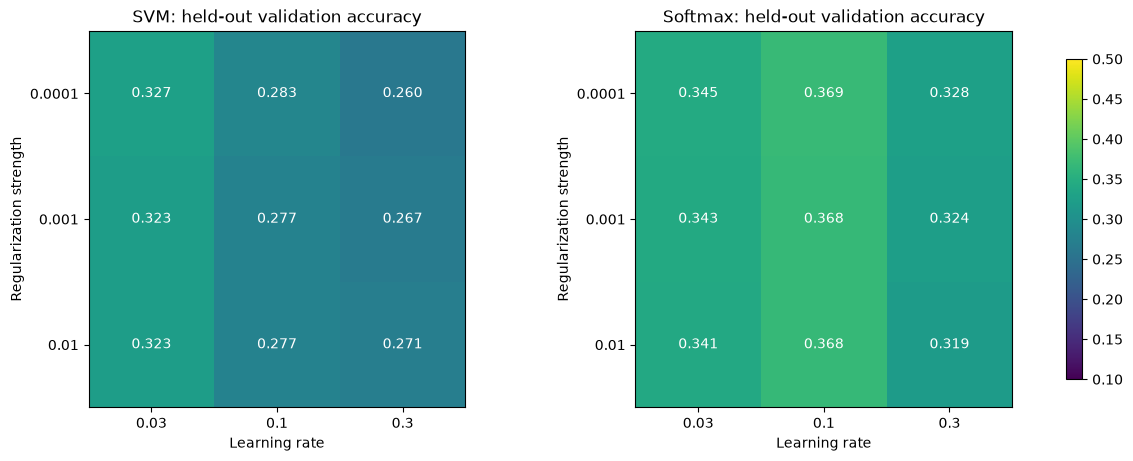

In [7]:
def result_matrix(results, loss_name, learning_rates, regularization_strengths):
    # place each matching validation accuracy at [reg_index, lr_index].
    matrix = np.zeros((len(regularization_strengths), len(learning_rates)))
    for result in results:
        if result["loss_name"] == loss_name:
            lr_index = learning_rates.index(result["learning_rate"])
            reg_index = regularization_strengths.index(result["regularization_strength"])
            matrix[reg_index, lr_index] = result["validation_accuracy"]
    return matrix


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for ax, loss_name in zip(axes, loss_functions):
    matrix = result_matrix(
        heldout_results, loss_name, learning_rates, regularization_strengths
    )
    image = ax.imshow(matrix, vmin=0.1, vmax=max(0.5, matrix.max()), cmap="viridis")
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            ax.text(column, row, f"{matrix[row, column]:.3f}", ha="center", va="center", color="white")
    ax.set(
        title=f"{loss_name}: held-out validation accuracy",
        xlabel="Learning rate", ylabel="Regularization strength",
        xticks=np.arange(len(learning_rates)),
        xticklabels=learning_rates,
        yticks=np.arange(len(regularization_strengths)),
        yticklabels=regularization_strengths,
    )
fig.colorbar(image, ax=axes, shrink=0.85)
plt.show()

## 6. Shortlist candidates

Held-out validation is inexpensive but sensitive to one split. Keep the two best configurations per loss for cross-validation. This reduces computation while allowing k-fold results to challenge the held-out ranking.

In [8]:
shortlisted_configs = {}
for loss_name in loss_functions:
    matching = [r for r in heldout_results if r["loss_name"] == loss_name]
    matching.sort(key=lambda r: r["validation_accuracy"], reverse=True)
    shortlisted_configs[loss_name] = [
        {"learning_rate": r["learning_rate"],
         "regularization_strength": r["regularization_strength"]}
        for r in matching[:2]
    ]
    print(loss_name, shortlisted_configs[loss_name])

SVM [{'learning_rate': 0.03, 'regularization_strength': 0.0001}, {'learning_rate': 0.03, 'regularization_strength': 0.001}]
Softmax [{'learning_rate': 0.1, 'regularization_strength': 0.0001}, {'learning_rate': 0.1, 'regularization_strength': 0.001}]


## 7. Create k folds

With `K=5`, every development example belongs to exactly one validation fold. In each run, concatenate the other four folds for training. The official test data does not participate.

### Exercise 4 — Implement fold creation

Return a list of index arrays after one seeded shuffle and `np.array_split`. Verify that their union contains every development index exactly once and that no pair overlaps.

In [9]:
def make_folds(num_examples: int, num_folds: int, seed: int) -> list[np.ndarray]:
    if num_folds < 2 or num_folds > num_examples:
        raise ValueError("num_folds must be between 2 and num_examples.")
    # shuffle all indices once and split them into num_folds pieces.
    split_rng = np.random.default_rng(seed)
    indices = split_rng.permutation(num_examples)
    fold_size = num_examples // num_folds
    folds = []
    for i in range(num_folds):
        start = i * fold_size
        end = start + fold_size if i < num_folds - 1 else num_examples
        folds.append(indices[start:end])

    return folds

folds = make_folds(DEVELOPMENT_SIZE, num_folds=5, seed=SEED + 2)
combined = np.concatenate(folds)
np.testing.assert_array_equal(np.sort(combined), np.arange(DEVELOPMENT_SIZE))
assert len(np.unique(combined)) == DEVELOPMENT_SIZE
print([len(fold) for fold in folds])

[1200, 1200, 1200, 1200, 1200]


## 8. Cross-validate shortlisted configurations

For every candidate and validation fold:

1. build training indices from all other folds;
2. fit the feature mean using only that fold's training data;
3. train from a fold-specific but configuration-independent seed;
4. measure accuracy on the held-out fold.

Report mean accuracy and standard deviation. Mean estimates typical performance; standard deviation reveals sensitivity to the particular split.

In [10]:
shortlisted_configs

{'SVM': [{'learning_rate': 0.03, 'regularization_strength': 0.0001},
  {'learning_rate': 0.03, 'regularization_strength': 0.001}],
 'Softmax': [{'learning_rate': 0.1, 'regularization_strength': 0.0001},
  {'learning_rate': 0.1, 'regularization_strength': 0.001}]}

In [11]:
shortlisted_configs.items()

dict_items([('SVM', [{'learning_rate': 0.03, 'regularization_strength': 0.0001}, {'learning_rate': 0.03, 'regularization_strength': 0.001}]), ('Softmax', [{'learning_rate': 0.1, 'regularization_strength': 0.0001}, {'learning_rate': 0.1, 'regularization_strength': 0.001}])])

### Exercise 5 — Implement cross-validation

In [12]:
def cross_validate_config(
    X_raw, y, folds, loss_function, *, learning_rate,
    regularization_strength, batch_size=128, num_iterations=150,
):
    fold_accuracies = []
    for validation_fold_index, validation_indices in enumerate(folds):
        # concatenate every non-validation fold into training indices.
        training_indices = np.concatenate([folds[i] for i in range(len(folds)) if i != validation_fold_index])
        train_X_raw = X_raw[training_indices]
        train_y = y[training_indices]
        # fit centering on fold training data and transform both portions.
        train_X, val_X, _ = center_from_training(train_X_raw, X_raw[validation_indices])
        # train using seed=SEED + 100 + validation_fold_index.
        W, b, loss_history = train_linear_classifier(
            train_X, train_y, loss_function,
            learning_rate=learning_rate,
            regularization_strength=regularization_strength,
            batch_size=batch_size,
            num_iterations=num_iterations,
            seed=SEED + 100 + validation_fold_index
        )
        # append validation-fold accuracy.
        val_y = y[validation_indices]
        val_accuracy = accuracy(val_X, val_y, W, b)
        fold_accuracies.append(val_accuracy)
    return np.asarray(fold_accuracies)


cross_validation_results = []
# cross-validate every shortlisted configuration for each loss.
for loss_name, configs in shortlisted_configs.items():
    for config in configs:
        fold_accuracies = cross_validate_config(
            X_development_raw, y_development, folds, loss_functions[loss_name],
            learning_rate=config["learning_rate"],
            regularization_strength=config["regularization_strength"]
        )
        cross_validation_results.append({
            "loss_name": loss_name,
            "learning_rate": config["learning_rate"],
            "regularization_strength": config["regularization_strength"],
            "fold_accuracies": fold_accuracies,
            "mean_accuracy": np.mean(fold_accuracies),
            "std_accuracy": np.std(fold_accuracies)
        })

assert len(cross_validation_results) == 4
for result in cross_validation_results:
    print(
        f"{result['loss_name']:7s} lr={result['learning_rate']:<4} "
        f"reg={result['regularization_strength']:<5g} "
        f"folds={np.round(result['fold_accuracies'], 3)} "
        f"mean={result['mean_accuracy']:.3f} std={result['std_accuracy']:.3f}"
    )

SVM     lr=0.03 reg=0.0001 folds=[0.334 0.341 0.328 0.342 0.309] mean=0.331 std=0.012
SVM     lr=0.03 reg=0.001 folds=[0.333 0.338 0.332 0.347 0.302] mean=0.330 std=0.015
Softmax lr=0.1  reg=0.0001 folds=[0.351 0.378 0.353 0.37  0.354] mean=0.361 std=0.011
Softmax lr=0.1  reg=0.001 folds=[0.352 0.379 0.353 0.371 0.356] mean=0.362 std=0.011


## 9. Select configurations without test feedback

Choose the highest mean cross-validation accuracy independently for SVM and softmax. If means are practically tied, lower fold variability or a simpler configuration can be a reasonable tie-breaker. Do not inspect test accuracy to break a tie.

In [13]:
selected_configs = {}
for loss_name in loss_functions:
    matching = [r for r in cross_validation_results if r["loss_name"] == loss_name]
    selected_configs[loss_name] = max(matching, key=lambda r: r["mean_accuracy"])
    print("Selected", loss_name, selected_configs[loss_name])

Selected SVM {'loss_name': 'SVM', 'learning_rate': 0.03, 'regularization_strength': 0.0001, 'fold_accuracies': array([0.33416667, 0.34083333, 0.32833333, 0.34166667, 0.30916667]), 'mean_accuracy': np.float64(0.33083333333333337), 'std_accuracy': np.float64(0.011867322079278608)}
Selected Softmax {'loss_name': 'Softmax', 'learning_rate': 0.1, 'regularization_strength': 0.001, 'fold_accuracies': array([0.35166667, 0.37916667, 0.35333333, 0.37083333, 0.35583333]), 'mean_accuracy': np.float64(0.3621666666666667), 'std_accuracy': np.float64(0.010885770528538615)}


## 10. Retrain and evaluate the test set once

After selection is finished, fit preprocessing on all development examples, train each selected configuration longer, and evaluate the official test set once.

This practice uses a `6000`-example development subset for runtime. Therefore, the final models are retrained on all data used in this experiment—not all 50,000 official training images. Scaling to the complete training set is a later engineering choice, not a reason to revisit test-driven decisions.

### Exercise 6 — Final retraining and test evaluation

Center development and test arrays using the complete development mean. Train each selected configuration for `500` iterations with batch size `256`, then compute one test accuracy. Store the trained parameters and results without changing any selected hyperparameter.

In [14]:
X_development, X_test, final_training_mean = center_from_training(
    X_development_raw, X_test_raw
)
final_results = {}

# TODO: retrain each selected loss/configuration and evaluate test exactly here.
for loss_name, loss_config in selected_configs.items():
    W, b, loss_history = train_linear_classifier(
        X_development,
        y_development,
        loss_functions[loss_name],
        learning_rate=loss_config["learning_rate"],
        regularization_strength=loss_config["regularization_strength"],
        batch_size=256,
        num_iterations=500,
        seed=SEED + 2,
    )
    test_accuracy = accuracy(X_test, y_test, W, b)
    final_results[loss_name] = {
        "loss_history": loss_history,
        "W": W,
        "b": b,
        "cv_mean_accuracy": np.mean(loss_config["fold_accuracies"]),
        "test_accuracy": test_accuracy
    }

for loss_name, result in final_results.items():
    print(
        f"{loss_name:7s}: CV mean={result['cv_mean_accuracy']:.3f}, "
        f"test accuracy={result['test_accuracy']:.3f}"
    )
assert set(final_results) == set(loss_functions)

SVM    : CV mean=0.331, test accuracy=0.347
Softmax: CV mean=0.362, test accuracy=0.377


## Reflection

Add a Markdown cell answering:

1. What is the difference between a learned parameter and a hyperparameter?
2. Why can training accuracy not select learning rate or regularization reliably?
3. Why must the test set remain outside both held-out search and cross-validation?
4. Why is preprocessing fitted separately inside every fold?
5. What does k-fold cross-validation average over?
6. What does high standard deviation across folds tell you?
7. Why did we shortlist with held-out validation before cross-validation?
8. Why might the held-out winner differ from the cross-validation winner?
9. Why must SVM and softmax be tuned independently?
10. Why is one final test result more trustworthy than repeatedly consulting test accuracy?
11. What limitations remain in this model-selection experiment?

Next we will move the reusable linear-classifier losses, prediction, and SGD logic into Python modules with focused tests, then update the roadmap before beginning neural networks and backpropagation.

1. Hyperparameters impact on how model is being trained and its process. Hyperparameters configure training or the model and are selected using validation evidence. Paramaters are learned during training. Parameters are learned from training data.
2. Cause model might perform well on training but poor on unseen previously data
3. If we use test during cross validation it simply becomes another validation dataset. If test results affect any decision, the test set becomes part of the selection process—effectively another validation set. The resulting test accuracy is biased toward the choices that happened to perform well on those particular test examples.
4. To make sure data is fitted only using train data. Preprocessing statistics are fitted only on the training portion of each fold.
5. Five-fold cross-validation produces five validation accuracies:
$a_1,a_2,a_3,a_4,a_5.$
Every fold serves as validation once and training data four times. We summarize them using:
$\bar a=\frac{1}{5}\sum_{k=1}^{5}a_k.$
Thus, cross-validation averages validation performance over five different train/validation partitions.
6. Model's performance highgly depends on datasplit
7. To check all options with cross-validation it requires a lot of computation. 5-fold cross validation means we train the model with same hyperparams 5 times
8. Cause result might depend on data-split we used during held-out experiment
9. SVM and softmax have different losses and gradient behavior:
- SVM updates only for active margin violations;
- softmax produces smooth probability-dependent gradients.
Consequently, the same learning rate and regularization strength can affect their optimization differently. Each should be tuned independently.
10. If all decisions are finalized before test evaluation, the test set provides an approximately independent estimate of performance on unseen data.
If we repeatedly consult test accuracy, we may start choosing hyperparameters or implementations that happen to perform well on that test set. Even without explicitly intending to, we gradually overfit our decisions to it.
11. - only 6,000 of 50,000 official training examples were used;
- the hyperparameter grid was small and coarse;
- cross-validation considered only candidates shortlisted by one held-out split;
- each fold/configuration used one initialization and minibatch sequence;
- training used a fixed iteration budget;
- batch size and initialization scale were not tuned;
- only mean-centering was considered;
- final models were not retrained on all 50,000 training examples;
- SVM and softmax remain raw-pixel linear classifiers with limited capacity;
- the experiment reports point estimates without confidence intervals.